Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [3]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\Expression_Genes_DESeq_R133C.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\DEA_Genes_DESeq_R133C.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\SraRunTable_Liu24.csv"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [4]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
expression_df.head()

,Gene,GSM7232994,GSM7232993,GSM7232992,GSM7232991,GSM7232990,GSM7232989,GSM7232988,GSM7232987,GSM7232986,GSM7232985,GSM7232984,GSM7232983
0,DDX11L2,0,2,16,4,26,2,14,8,2,6,12,8
1,WASH7P,136,31,92,65,47,39,4,76,56,74,87,30
2,MIR1302-2HG,0,2,0,0,2,1,0,2,0,0,3,1
3,OR4G4P,0,0,0,0,0,14,0,0,0,0,0,0
4,ENSG00000290826,0,0,0,0,6,2,0,5,12,2,6,8


DEA - Import

In [5]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TOP2A,2121.971260,-6.449924,0.276533,-23.324286,2.514150e-120,7.198765e-116
1,SPARC,7882.357474,-4.930263,0.227364,-21.684454,2.876527e-104,4.118180e-100
2,NR2F1,1370.210968,-6.196240,0.290525,-21.327767,6.273140e-101,5.987294e-97
3,NR2F2,1706.858923,-5.681525,0.272447,-20.853710,1.410497e-96,1.009669e-92
4,FLNA,11957.923093,-4.826371,0.233356,-20.682426,4.986857e-95,2.855774e-91


Volcano plot

Classification
Non-significant    15940
Up-regulated        7219
Down-regulated      5474
Name: count, dtype: int64
12693
Total tes:
28633


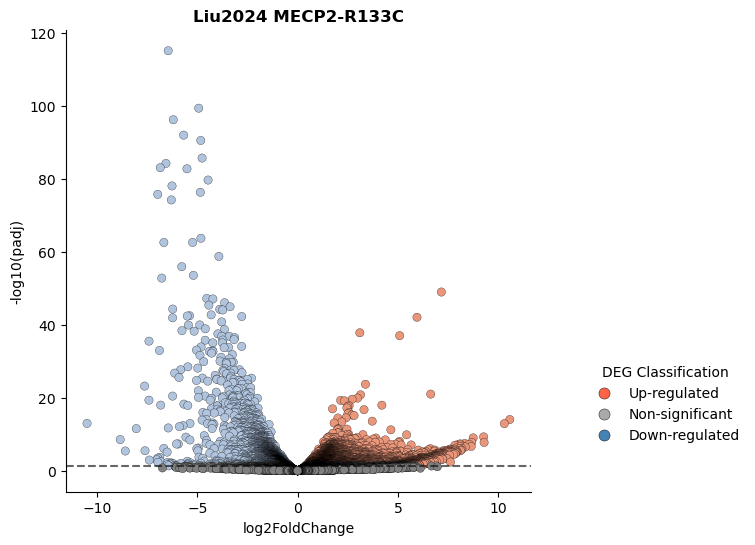

In [22]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)
    ax.set_title('Liu2024 MECP2-R133C', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['Gene'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['Gene'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['Gene'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['Gene'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DEG Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(dea_df))

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False)
    set_lines_and_labels(ax)
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [23]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)
clinical_data = clinical_data[clinical_data['genotype'].isin(['MECP2.WT', 'MECP2.R133C'])]

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
filtered_samples = clinical_data['Sample Name'].to_list()
log2cpm_df = log2cpm_df[filtered_samples]
print(log2cpm_df.head())


# Process clinical data
print(clinical_data.columns)
clinical_data = clinical_data[['Sample Name', 'genotype', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample Name', how = 'left')

pca_df.head()

   GSM7232994  GSM7232993  GSM7232992  GSM7232988  GSM7232987  GSM7232986
0    0.000000    0.123748    0.748255    0.964406    0.441904    0.138176
1    2.548818    1.255928    2.295317    0.346859    2.139064    1.931444
2    0.000000    0.123748    0.000000    0.000000    0.123797    0.000000
3    0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
4    0.000000    0.000000    0.000000    0.000000    0.291601    0.680845
Index(['Run', 'Assay Type', 'AvgSpotLen', 'Bases', 'BioProject', 'BioSample',
       'Bytes', 'cell_type', 'Center Name', 'Collection_Date', 'Consent',
       'DATASTORE filetype', 'DATASTORE provider', 'DATASTORE region',
       'Experiment', 'genotype', 'geo_loc_name_country',
       'geo_loc_name_country_continent', 'geo_loc_name', 'Instrument',
       'Library Name', 'LibraryLayout', 'LibrarySelection', 'LibrarySource',
       'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version',
       'Sample Name', 'source_name', 'SRA Study', 'cell_

,Sample Name,PC1,PC2,genotype,Run
0,GSM7232994,-143.514373,-28.073250,MECP2.WT,SRR24321482
1,GSM7232993,-97.840278,1.465203,MECP2.WT,SRR24321483
2,GSM7232992,-120.897951,-57.957383,MECP2.WT,SRR24321484
3,GSM7232988,239.037120,-90.141366,MECP2.R133C,SRR24321488
4,GSM7232987,42.767633,90.236782,MECP2.R133C,SRR24321489


PCA - Graph

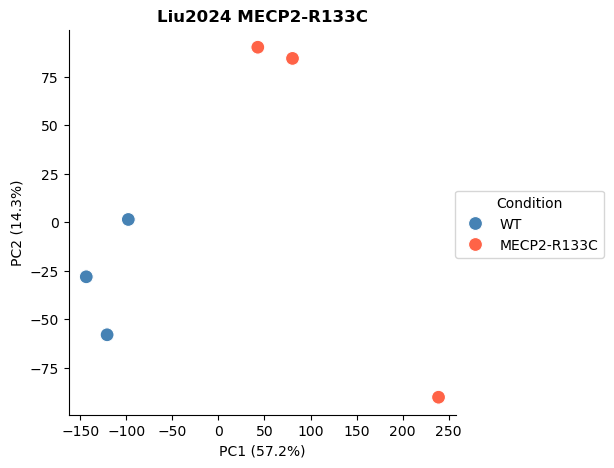

In [24]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'MECP2-R133C' : 'tomato'}
pca_df['genotype'] = pca_df['genotype'].replace({'MECP2.R133C' : 'MECP2-R133C',
                                                 'MECP2.WT' : 'WT'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'genotype', s = 100)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Liu2024 MECP2-R133C", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

  Sample Name     genotype          Run
0  GSM7232994     MECP2.WT  SRR24321482
1  GSM7232993     MECP2.WT  SRR24321483
2  GSM7232992     MECP2.WT  SRR24321484
3  GSM7232991  MECP2.R168X  SRR24321485
4  GSM7232990  MECP2.R168X  SRR24321486


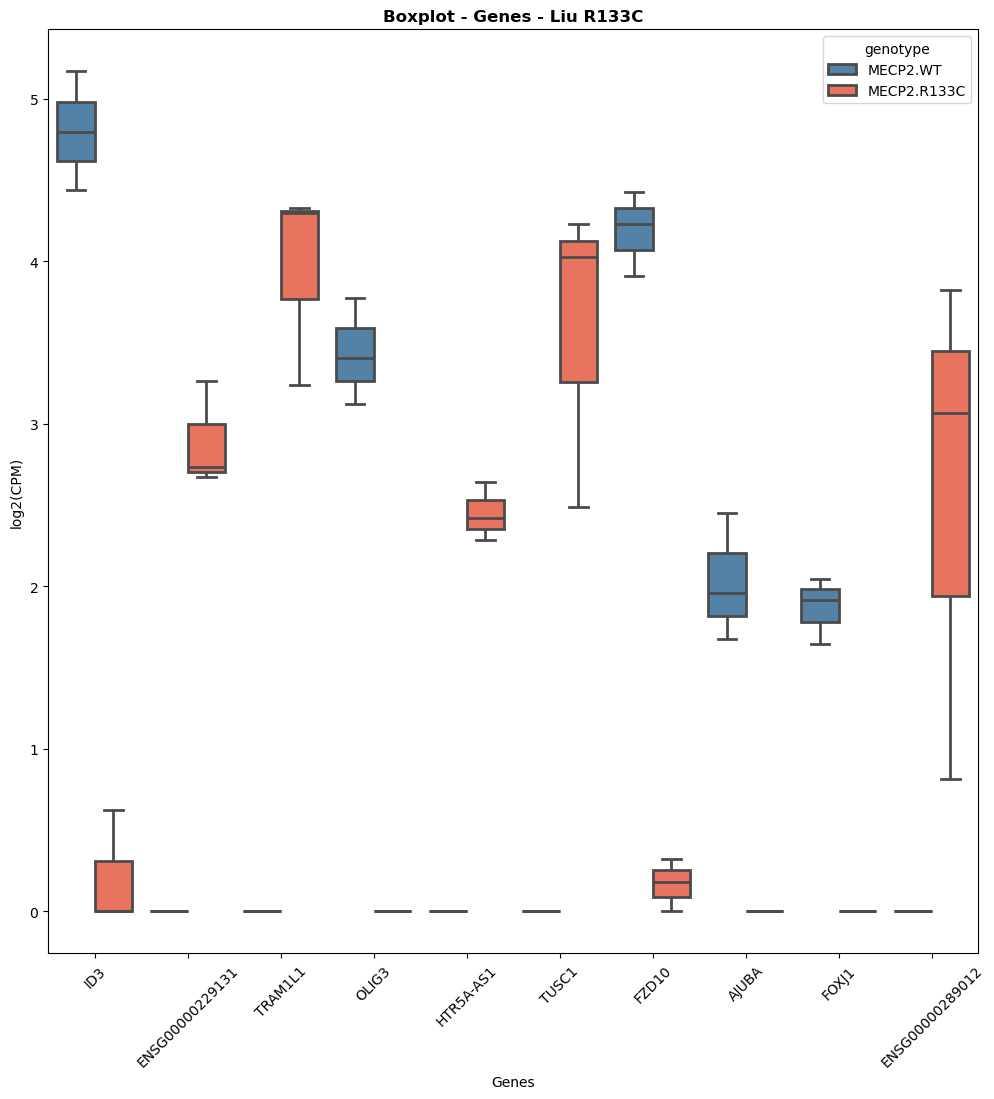

In [21]:
# Assemble the new table
log2cpm_df.insert(0, 'Gene', genes)
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample Name', how = 'left')
long_df = long_df[long_df['genotype'].isin(['MECP2.R133C', 'MECP2.WT'])]

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'MECP2.R133C' : 'tomato',
                   'MECP2.WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'genotype', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - Genes - Liu R133C', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Genes')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)

